# **Multiagent design with DeepAgent framework**




# **Agent implementation with all steps exlained**

## **Intsallation and importing of dependencies**

*   Deep Agent package from Langchain
*   Langchain community tool
*   Communication tools with  OpenAI

Optional

*   Communication package with Google in case Gemini models are preferred

API keys are imported from the Colab stored userdata




In [1]:
%reset -f
!pip install deepagents tavily-python langchain-openai langchain_community
!pip install langchain_google_genai

In [2]:
#@title Necessary imports

from google.colab import userdata # For API keys
import os # for environmental variables
from io import StringIO # to act like a file but you don’t want to create an actual file on disk.

## Structure processings
import json
from typing import Optional, Iterable, List, Dict, Any, Set, Tuple
import datetime
import requests
import re
import pandas as pd

# LLM-related imports
from langchain.chat_models import init_chat_model
#from langchain_google_genai import ChatGoogleGenerativeAI
from deepagents import create_deep_agent

from typing import Optional, Literal, Tuple
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.prompts import PromptTemplate
from langchain.agents import create_agent

from langchain_core.messages import SystemMessage, HumanMessage

# Part needed to inspect xlsx
from IPython.display import display, HTML
import concurrent.futures

In [3]:
# @title Imports using colab stored keys
#from google.colab import userdata
OPENAI_API_KEY=userdata.get('api-key-MicRisk')
Langsmith_key=userdata.get('langsmith')
# ANTHROPIC_API_KEY=userdata.get('anthropic')
# GEMINI_API_KEY=userdata.get('gemini')

In [4]:
# @title Specifying global variables  for Langsmith tracing and LLM calls
#import os
# os.environ["GEMINI_API_KEY"] =GEMINI_API_KEY
os.environ["OPENAI_API_KEY"] =OPENAI_API_KEY
# os.environ["LANGSMITH_API_KEY"] =Langsmith_key
# os.environ["LANGSMITH_TRACING"] ="true"
# os.environ["LANGSMITH_PROJECT"] ="OpenFSMR"
# os.environ["LANGSMITH_ENDPOINT"]="https://eu.api.smith.langchain.com"
# os.environ["ANTHROPIC_API_KEY"] =ANTHROPIC_API_KEY
#os.environ["TAVILY_API_KEY"] =TAVILY_API_KEY

## **Specifying Wikidata tools**

In [5]:
# @title Uploading the stored list of wikidata properties. See Wikidata_tools\Property_list_retrieval

# Path to your uploaded Wikidata properties file
FILE_PATH = "/content/wikidata_properties.json"

# Your existing minimal PROPERTY_LABELS (overrides)
PROPERTY_LABELS = {}

def load_property_labels_from_file(path: str) -> dict:
    """
    Load property labels from JSON.

    Expected format:
      {
         "P10": "video",
         "P101": "field of work",
         ...
      }

    Returns:
        dict: { "Pxxx": "label", ... }
    """
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # The uploaded file is already a dict {pid: label}
    if isinstance(data, dict):
        return data

    raise ValueError("Unexpected JSON structure: expected a dictionary of PID→label.")


# Load the big Wikidata property dictionary
DYNAMIC_PROPERTY_LABELS = load_property_labels_from_file(FILE_PATH)

# Merge → existing manual PROPERTY_LABELS take precedence
for pid, label in DYNAMIC_PROPERTY_LABELS.items():
    PROPERTY_LABELS.setdefault(pid, label)

print("Loaded", len(DYNAMIC_PROPERTY_LABELS), "properties from JSON.")
print("Total PROPERTY_LABELS now:", len(PROPERTY_LABELS))

# Quick preview
example_keys = list(PROPERTY_LABELS.keys())[:20]
print({k: PROPERTY_LABELS[k] for k in example_keys})

Loaded 13065 properties from JSON.
Total PROPERTY_LABELS now: 13065
{'P10': 'video', 'P101': 'field of work', 'P102': 'member of political party', 'P103': 'native language', 'P105': 'taxon rank', 'P106': 'occupation', 'P108': 'employer', 'P109': 'signature', 'P110': 'illustrator', 'P111': 'measured physical quantity', 'P112': 'founded by', 'P113': 'airline hub', 'P114': 'airline alliance', 'P115': 'home venue', 'P117': 'chemical structure', 'P118': 'league or competition', 'P119': 'place of burial', 'P121': 'item operated', 'P122': 'basic form of government', 'P123': 'publisher'}


In [6]:
# @title Defining tools for the communication with wikidata.See Deep_Agent\Deep_Agent_implementation\Wikidata_tools
# from typing import Iterable, List, Dict, Any
# import datetime
# import requests

# Wikidata API base URL
WIKIDATA_API_URL = "https://www.wikidata.org/w/api.php"

HEADERS = {
    "User-Agent": "MyReActAgent/0.1 Linked_data"
}


def _extract_time_string(wikidata_time: str) -> str:
    """
    Convert Wikidata time format '+1955-07-26T00:00:00Z' to '1955-07-26'.
    Falls back to the original string if parsing fails.
    """
    try:
        if wikidata_time.startswith("+") or wikidata_time.startswith("-"):
            wikidata_time = wikidata_time[1:]
        dt = datetime.datetime.fromisoformat(wikidata_time.replace("Z", "+00:00"))
        return dt.date().isoformat()
    except Exception:
        return wikidata_time


def _collect_referenced_item_ids(entities: Dict[str, Any]) -> List[str]:
    """
    From an entities dict (wbgetentities result), collect referenced item IDs (Qxxx)
    from the subset of properties we care about.
    """
    referenced_ids = set()
    for entity_id, entity in entities.items():
        claims = entity.get("claims", {})
        for pid in PROPERTY_LABELS.keys():
            for claim in claims.get(pid, []):
                mainsnak = claim.get("mainsnak", {})
                datavalue = mainsnak.get("datavalue", {})
                value = datavalue.get("value")
                if (
                    isinstance(value, dict)
                    and value.get("entity-type") == "item"
                    and "id" in value
                ):
                    referenced_ids.add(value["id"])
    # remove the original entity ids; we only need labels for referenced ones
    referenced_ids -= set(entities.keys())
    return list(referenced_ids)


def _get_entities(ids: Iterable[str], language: str = "en") -> Dict[str, Any]:
    """
    Helper to call wbgetentities for a list of Q-ids and return the 'entities' map.
    """
    ids_list = list(ids)
    if not ids_list:
        return {}

    params = {
        "action": "wbgetentities",
        "ids": "|".join(ids_list),
        "format": "json",
        "languages": language,
        "props": "labels|descriptions|claims",
    }
    response = requests.get(
        WIKIDATA_API_URL,
        params=params,
        headers=HEADERS,  # <-- important for avoiding 403
        timeout=15,
    )
    response.raise_for_status()
    data = response.json()
    return data.get("entities", {})


def _get_entity_labels(ids: Iterable[str], language: str = "en") -> Dict[str, str]:
    """
    Get labels for item IDs (e.g. Q5, Q30) in the given language.
    """
    ids_list = list(ids)
    if not ids_list:
        return {}

    params = {
        "action": "wbgetentities",
        "ids": "|".join(ids_list),
        "format": "json",
        "languages": language,
        "props": "labels",
    }
    response = requests.get(
        WIKIDATA_API_URL,
        params=params,
        headers=HEADERS,  # <-- important for avoiding 403
        timeout=15,
    )
    response.raise_for_status()
    data = response.json()
    entities = data.get("entities", {})

    labels = {}
    for eid, entity in entities.items():
        label_obj = entity.get("labels", {}).get(language)
        if label_obj:
            labels[eid] = label_obj.get("value")
    return labels

def get_wikidata_definition(
    entity_id: str,
    language: str = "en",
) -> Optional[Dict[str, Any]]:
    """
    Tool: Given a single Wikidata entity ID (e.g. 'Q42'),
    construct an enriched definition for that term using Wikidata entity data.

    Returns:
        A dict like:
        {
          "id": "Q42",
          "label": "...",
          "description": "...",
          "definition": "...",
          "url": "https://www.wikidata.org/wiki/Q42",
          "facts": { ... }
        }
        or None if the entity cannot be retrieved.
    """
    if not entity_id:
        return None

    # 1) Get entity data for this single ID
    entities = _get_entities([entity_id], language=language)
    if entity_id not in entities:
        # Nothing found for this ID
        return None

    entity = entities[entity_id]

    # 2) Collect referenced item ids for properties of interest, to get nicer labels
    referenced_item_ids = _collect_referenced_item_ids({entity_id: entity})
    referenced_labels = _get_entity_labels(referenced_item_ids, language=language)

    def _value_to_string(datavalue: Dict[str, Any]) -> str:
        """
        Convert a Wikidata datavalue into a human-readable string, using
        referenced_labels when possible.
        """
        if not datavalue:
            return ""

        value = datavalue.get("value")
        vtype = datavalue.get("type")

        if vtype == "wikibase-entityid" and isinstance(value, dict):
            eid = value.get("id")
            return referenced_labels.get(eid, eid or "")

        if vtype == "time" and isinstance(value, dict):
            return _extract_time_string(value.get("time", ""))

        if vtype == "globecoordinate" and isinstance(value, dict):
            lat = value.get("latitude")
            lon = value.get("longitude")
            if lat is not None and lon is not None:
                return f"{lat}, {lon}"
            return str(value)

        # Fallback: just stringify
        return str(value)

    labels = entity.get("labels", {})
    descriptions = entity.get("descriptions", {})
    claims = entity.get("claims", {})

    label = labels.get(language, {}).get("value") or entity_id
    description = descriptions.get(language, {}).get("value")

    # Build structured "facts" from selected properties
    facts: Dict[str, List[str]] = {}

    for pid, human_label in PROPERTY_LABELS.items():
        prop_claims = claims.get(pid, [])
        values: List[str] = []
        for claim in prop_claims:
            mainsnak = claim.get("mainsnak", {})
            datavalue = mainsnak.get("datavalue")
            if datavalue:
                s = _value_to_string(datavalue)
                if s:
                    values.append(s)
        if values:
            facts[human_label] = values

    # Construct definition text
    definition_parts: List[str] = []
    if description:
        definition_parts.append(description.rstrip("."))

    if facts:
        fact_strings = []
        for human_label, values in facts.items():
            joined_vals = ", ".join(values)
            fact_strings.append(f"{human_label}: {joined_vals}")
        definition_parts.append("Key facts: " + "; ".join(fact_strings))

    if not definition_parts:
        definition_parts.append(
            f"{label} (no textual description available in Wikidata)."
        )

    definition = ". ".join(definition_parts).strip()
    if not definition.endswith("."):
        definition += "."

    return {
        "id": entity_id,
        "label": label,
        "description": description,
        "definition": definition,
        "url": f"https://www.wikidata.org/wiki/{entity_id}",
        "facts": facts,
    }

def resolve_qids_and_pids_in_definition(
    enriched_result: Dict[str, Any],
    language: str = "en",
) -> Dict[str, Any]:
    """
    Given a single enriched entity from `get_wikidata_definition`,
    replace:
      - Q-IDs (e.g. 'Q183') with their Wikidata labels
      - P-IDs (e.g. 'P2076') with their property labels from PROPERTY_LABELS

    Replacement is applied to:
      - the 'definition' string
      - all string values inside the 'facts' dict

    Args:
        enriched_result: output of get_wikidata_definition (a dict for one entity)
        language: label language to use when resolving Q-IDs

    Returns:
        A NEW dict with Q- and P-IDs replaced by labels.
        (Original dict is not mutated.)
    """
    if not enriched_result:
        return enriched_result

    qid_pattern = re.compile(r"\bQ\d+\b")
    pid_pattern = re.compile(r"\bP\d+\b")

    # 1) Collect all Q-IDs that appear in definition or facts
    all_qids: Set[str] = set()

    # From definition text
    definition = enriched_result.get("definition") or ""
    all_qids.update(qid_pattern.findall(definition))

    # From facts (only string values)
    facts = enriched_result.get("facts") or {}
    if isinstance(facts, dict):
        for vals in facts.values():
            for v in vals:
                if isinstance(v, str):
                    all_qids.update(qid_pattern.findall(v))

    # 2) Resolve Q-IDs -> labels using Wikidata (in chunks, though usually few)
    entity_labels: Dict[str, str] = {}
    if all_qids:
        qid_list = list(all_qids)
        chunk_size = 50

        for i in range(0, len(qid_list), chunk_size):
            chunk = qid_list[i : i + chunk_size]
            chunk_labels = _get_entity_labels(chunk, language=language)
            entity_labels.update(chunk_labels)

    # 3) Helper to replace Q-IDs and P-IDs in any string
    def _replace_ids_in_text(text: str) -> str:
        # First replace Q-IDs with entity labels
        text = qid_pattern.sub(
            lambda m: entity_labels.get(m.group(0), m.group(0)),
            text,
        )
        # Then replace P-IDs with property labels from PROPERTY_LABELS
        text = pid_pattern.sub(
            lambda m: PROPERTY_LABELS.get(m.group(0), m.group(0)),
            text,
        )
        return text

    # 4) Build a new dict with replaced IDs
    new_item = dict(enriched_result)  # shallow copy

    # Replace in definition
    definition = enriched_result.get("definition")
    if isinstance(definition, str):
        new_item["definition"] = _replace_ids_in_text(definition)

    # Replace inside facts strings
    facts = enriched_result.get("facts")
    if isinstance(facts, dict):
        new_facts: Dict[str, list] = {}
        for key, vals in facts.items():
            new_vals: list = []
            for v in vals:
                if isinstance(v, str):
                    new_vals.append(_replace_ids_in_text(v))
                else:
                    new_vals.append(v)
            new_facts[key] = new_vals
        new_item["facts"] = new_facts

    return new_item

def WikidataEntityDetails (q: str):
     """
     Fetch full Wikidata details for a given entity (e.g. 'Q159').
     Input should be Q-ID only, and output is the JSON of that entity
     """

     raw = get_wikidata_definition(q) # Get definition containing Q-ids and P-ids
     resolved = resolve_qids_and_pids_in_definition(raw) # Enrich the definition
     return resolved


def get_nested_value(o: dict, path: list) -> any:
    """
    Safely walk through nested dicts and lists by keys/indexes.
    Returns None if any KeyError, IndexError, or TypeError occurs.
    """
    current = o
    for key in path:
        try:
            current = current[key]
        except (KeyError, IndexError, TypeError):
            return None
    return current


def WikidataEntitySearch(
    search: str,
    entity_type: str = "item",
    url: str = "https://www.wikidata.org/w/api.php",
    user_agent_header: str = 'DeepWikidataMapper/0.1',
    srqiprofile: str = None,
) -> Optional[str]:
    """
    Search Wikidata entities for a given query.

    Args:
        search: Text to search for (e.g. "Berlin").
        entity_type: Type of entity to search ('item' or 'property').
        url: Wikidata API URL.
        user_agent_header: User-Agent string for requests.
        srqiprofile: Search profile for Wikidata API.

    Returns:
        The Q-ID or P-ID of the top result, or an error message if not found.
    """
    headers = {"Accept": "application/json"}
    if user_agent_header is not None:
        headers["User-Agent"] = user_agent_header

    if entity_type == "item":
        srnamespace = 0
        srqiprofile = "classic_noboostlinks" if srqiprofile is None else srqiprofile
    elif entity_type == "property":
        srnamespace = 120
        srqiprofile = "classic" if srqiprofile is None else srqiprofile
    else:
        raise ValueError("entity_type must be either 'property' or 'item'")

    params = {
        "action": "query",
        "list": "search",
        "srsearch": search,
        "srnamespace": srnamespace,
        "srlimit": 1,
        "srqiprofile": srqiprofile,
        "srwhat": "text",
        "format": "json",
    }

    response = requests.get(url, headers=headers, params=params)

    if response.status_code == 200:
        title = get_nested_value(response.json(), ["query", "search", 0, "title"])
        if title is None:
            return f"I couldn't find any {entity_type} for '{search}'. Please rephrase your request and try again"
        # if there is a prefix, strip it off
        return title.split(":")[-1]
    else:
        return "Sorry, I got an error. Please try again."


# def WikidataEntityDetails (q: str):
#     """
#     Fetch full Wikidata details for a given entity (e.g. 'Russia Q159').
#     Input should be the label plus Q-ID, and output is the JSON of that entity
#     """
#     wikidata = WikidataQueryRun(api_wrapper=WikidataAPIWrapper())

#     return wikidata.run(q)




## **Specifying Bioportal tools**

### **Bioportal term similarity search**

In [7]:
bioportal_api = userdata.get('bioportal-key')
BASE_URL = "https://data.bioontology.org"

In [8]:
#from typing import List, Dict, Any, Tuple

def find_term_in_ontology(
    term: str,
    ontology: str,
    exact: bool = True,
    case_sensitive: bool = False
) -> Tuple[str, str]:
    """
    Function to search for a given term in a specified ontology without retrieving
    the definition.

    Searches a specified ontology in the BioPortal API for a given term and returns:
      - the mapped ID
      - the mapping type: "exact" or "synonym"

    If no matches are found and exact=True, the search is retried with exact=False.

    Parameters
    ----------
    term : str
        Search term.
    ontology : str
        Ontology acronym.
    exact : bool, optional
        If True, attempt exact prefLabel match first.
    case_sensitive : bool, optional
        If True, case-sensitive matching is used and no .lower() transformations occur.

    Returns
    -------
    Tuple[str, str]
        (mapped_id, match_type)
        Returns ("", "") if no match found.
    """

    params = {
        "q": term,
        "ontologies": ontology,
        "require_exact_match": str(exact).lower(),
        "include": "prefLabel,definition,synonym,notation,cui,semanticType",
        "pagesize": 20,
        "apikey": bioportal_api
    }
    # To handle errors and avoid system crash, occured when incorrect ontologies were used.
    try:
        resp = requests.get(f"{BASE_URL}/search", params=params, timeout=15)
        resp.raise_for_status()
        entries = resp.json().get("collection", [])
    except (requests.RequestException, ValueError, KeyError):
        # Treat errors as "no results"
        if exact:
            return find_term_in_ontology(
                term,
                ontology,
                exact=False,
                case_sensitive=case_sensitive
            )
        return "", ""

    # Apply case sensitivity rule
    if case_sensitive:
        term_cmp = term               # keep original case
    else:
        term_cmp = term.lower()       # lowercase for case-insensitive match

    # --- Filter logic ---
    filtered = []

    if exact:
        for e in entries:
            label = e.get("prefLabel", "")
            label_cmp = label if case_sensitive else label.lower()
            if label_cmp == term_cmp:
                filtered.append(e)
        match_type = "exact"
    else:
        for e in entries:
            syns = e.get("synonym") or []
            if isinstance(syns, str):
                syns = [syns]

            for s in syns:
                syn_cmp = s if case_sensitive else s.lower()
                if syn_cmp == term_cmp:
                    filtered.append(e)
                    break
        match_type = "synonym"

    # If nothing found and this was an exact search → retry as synonym search
    if not filtered and exact:
        return find_term_in_ontology(
            term,
            ontology,
            exact=False,
            case_sensitive=case_sensitive
        )

    # Still nothing found
    if not filtered:
        return "", ""

    # Extract mapped ID
    first = filtered[0]
    mapped_id = first.get("@id", first.get("id", ""))

    return mapped_id, match_type


In [9]:
find_term_in_ontology('Dessert','FOODON')

('http://purl.obolibrary.org/obo/FOODON_03303220', 'synonym')

## **Bioportal search with the definition retrieval**

In [10]:
#from typing import List, Dict, Any

BASE_URL = "https://data.bioontology.org"
BIOPORTAL_API_KEY=userdata.get('bioportal-key')


def _extract_definition(e: Dict[str, Any]) -> str:
    """
    Extract a definition string from a BioPortal entry.
    Returns the first non-empty definition if available, else empty string.
    """
    defs = e.get("definition") or []

    if isinstance(defs, list):
        for d in defs:
            if isinstance(d, str) and d.strip():
                return d.strip()
        return ""

    if isinstance(defs, str) and defs.strip():
        return defs.strip()

    return ""


def find_term_in_ontology_with_definition(
    term: str,
    ontology: str,
    exact: bool = True,
    case_sensitive: bool = False
) -> str:
    """
    Searches an ontology in BioPortal and returns a *single output string* with:
        mapped_id: ...
        matching_type: ...
        definition: ...

    If no match found -> returns an empty string.
    """

    params = {
        "q": term,
        "ontologies": ontology,
        "require_exact_match": str(exact).lower(),
        "include": "prefLabel,definition,synonym,notation,cui,semanticType",
        "pagesize": 20,
        "apikey": bioportal_api,
    }

    resp = requests.get(f"{BASE_URL}/search", params=params, timeout=15)
    resp.raise_for_status()
    entries = resp.json().get("collection", [])

    # Case sensitivity
    term_cmp = term if case_sensitive else term.lower()

    filtered: List[Dict[str, Any]] = []

    # ---------------------------
    # MATCHING LOGIC
    # ---------------------------
    if exact:
        for e in entries:
            label = e.get("prefLabel", "")
            label_cmp = label if case_sensitive else label.lower()
            if label_cmp == term_cmp:
                filtered.append(e)
        match_type = "exact"
    else:
        for e in entries:
            syns = e.get("synonym") or []
            if isinstance(syns, str):
                syns = [syns]
            for s in syns:
                syn_cmp = s if case_sensitive else s.lower()
                if syn_cmp == term_cmp:
                    filtered.append(e)
                    break
        match_type = "synonym"

    # Retry using synonym search if exact failed
    if not filtered and exact:
        return find_term_in_ontology_with_definition(
            term,
            ontology,
            exact=False,
            case_sensitive=case_sensitive
        )

    if not filtered:
        return ""  # no match at all

    # ---------------------------
    # EXTRACT FIELDS
    # ---------------------------
    first = filtered[0]
    mapped_id = first.get("@id", first.get("id", ""))
    definition = _extract_definition(first)

    # ---------------------------
    # FORMAT FINAL OUTPUT STRING
    # ---------------------------
    result = (
        f"mapped_id: {mapped_id}, "
        f"mapped_type: {match_type}, "
        f"definition: {definition}"
    )

    return result

def find_indirect_definition(term: str, ontology: str) -> Optional[Dict[str, str]]:
    """
    Look up mappings for (term, ontology) and try to pull a definition
    from the *mapped* term in another ontology.

    Returns
    -------
    None or {
        "definition": <definition text>,
        "iri": <mapped class IRI>,
        "source_onto": <ontology link of mapped class>
    }
    """

    # 1) Search for the term in the given ontology to get its mappings link
    search_params = {
        "q": term,
        "ontologies": ontology,
        "require_exact_match": "true",
        "pagesize": 1,
        "apikey": BIOPORTAL_API_KEY,
    }
    try:
        r = requests.get(f"{BASE_URL}/search", params=search_params, timeout=15)
        r.raise_for_status()
    except requests.RequestException:
        return None

    coll = r.json().get("collection", [])
    if not coll:
        return None

    mappings_url = coll[0].get("links", {}).get("mappings")
    if not mappings_url:
        return None

    # 2) Fetch the mapping records
    try:
        mresp = requests.get(
            mappings_url, params={"apikey": BIOPORTAL_API_KEY}, timeout=15
        )
        mresp.raise_for_status()
    except requests.RequestException:
        return None

    mdata = mresp.json()
    records: List[Dict[str, Any]] = (
        mdata if isinstance(mdata, list) else mdata.get("collection", [])
    )

    # 3) Iterate over mappings and follow the target class's self link
    for rec in records:
        classes = rec.get("classes", [])
        if len(classes) < 2:
            continue

        target = classes[1]  # mapped-to class
        iri = target.get("@id", "")
        links = target.get("links", {}) or {}

        self_link = links.get("self")
        onto_link = links.get("ontology", "")

        if not self_link:
            continue

        # 4) Fetch the full class record to get its definition
        try:
            c = requests.get(
                self_link, params={"apikey": BIOPORTAL_API_KEY}, timeout=15
            )
            c.raise_for_status()
        except requests.RequestException:
            continue

        entry = c.json()
        defs = entry.get("definition") or []

        text = None
        if isinstance(defs, list) and defs:
            for d in defs:
                if isinstance(d, str) and d.strip():
                    text = d.strip()
                    break
        elif isinstance(defs, str) and defs.strip():
            text = defs.strip()

        if text:
            return {
                "definition": text,
                "iri": iri,
                "source_onto": onto_link,  # full ontology URL, no guessing
            }

    # No mapped term with a definition found
    return None

In [11]:
def _parse_mapped_output(output: str) -> Dict[str, str]:
    """
    Parse the string from find_term_in_ontology_with_definition:
      "mapped_id: ..., mapped_type: ..., definition: ..."
    into a dict.
    """
    result: Dict[str, str] = {"mapped_id": "", "mapped_type": "", "definition": ""}

    if not output:
        return result

    parts = [p.strip() for p in output.split(",")]
    for part in parts:
        if ":" not in part:
            continue
        key, value = part.split(":", 1)
        key = key.strip()
        value = value.strip()
        if key in result:
            result[key] = value

    return result


def find_best_definition(
    term: str,
    ontology: str,
    exact: bool = True,
    case_sensitive: bool = False
) -> Optional[Dict[str, str]]:
    """
    Function to search for a given term in a specified ontology with retrieving the
    definition information

    Combines direct and indirect definition lookup.

    Output schema:

    {
        "mapped_id": ...,
        "mapped_type": ...,
        "definition": ...,
        "definition_source": "original" | "indirect" | "",
        "definition_source_ontology": <ontology URL or empty>,
    }
    """
    try:
        direct_str = find_term_in_ontology_with_definition(
            term, ontology, exact=exact, case_sensitive=case_sensitive
        )

        if not direct_str:
            return None

        direct = _parse_mapped_output(direct_str)
        mapped_id = direct.get("mapped_id", "").strip()
        mapped_type = direct.get("mapped_type", "").strip()
        definition = direct.get("definition", "").strip()

        if not mapped_id:
            return None

        # -------------------------------------------------
        # CASE 1: Direct definition found
        # -------------------------------------------------
        if definition:
            return {
                "mapped_id": mapped_id,
                "mapped_type": f'{mapped_type}+Definition',
                "definition": definition,
                "definition_source": "original",
                "definition_source_ontology": mapped_id
            }

        # -------------------------------------------------
        # CASE 2: No direct definition → try indirect
        # -------------------------------------------------
        indirect = find_indirect_definition(term, ontology)

        if indirect and indirect.get("definition"):
            return {
                "mapped_id": mapped_id,
                "mapped_type": f'{mapped_type}+Definition',
                "definition": indirect["definition"],
                "definition_source": "indirect",
                "definition_source_ontology": indirect.get("iri", "")
            }

        # -------------------------------------------------
        # CASE 3: No definition found anywhere
        # -------------------------------------------------
        return {
            "mapped_id": mapped_id,
            "mapped_type": f'{mapped_type}+Unverified',
            "definition": "",
            "definition_source": "",
            "definition_source_ontology": ""
        }

    except Exception:
      return None

In [12]:
find_best_definition('Drying','IOBC')

{'mapped_id': 'http://purl.jp/bio/4/id/200906047974477893',
 'mapped_type': 'exact+Definition',
 'definition': 'The process of removing a solvent from a substance. [CHMO]',
 'definition_source': 'indirect',
 'definition_source_ontology': 'http://purl.allotrope.org/ontologies/process#AFP_0001876'}

In [13]:
find_best_definition('Dessert','FOODON')

{'mapped_id': 'http://purl.obolibrary.org/obo/FOODON_03303220',
 'mapped_type': 'synonym+Definition',
 'definition': 'A food product served during the dessert course of a meal.',
 'definition_source': 'original',
 'definition_source_ontology': 'http://purl.obolibrary.org/obo/FOODON_03303220'}

In [14]:
find_best_definition('Fat','SNOMEDCT')

{'mapped_id': 'http://purl.bioontology.org/ontology/SNOMEDCT/256674009',
 'mapped_type': 'exact+Definition',
 'definition': 'ester of glycerol with fatty acids; generally odorless, colorless, and tasteless if pure; fats are insoluble in water, soluble in most organic solvents; they occur in animal and vegetable tissue.',
 'definition_source': 'indirect',
 'definition_source_ontology': 'http://purl.bioontology.org/ontology/CSP/1743-9596'}

## **Defining SKOS matching tool**

In [15]:
# @title Defining tools for the communication with wikidata.See Deep_Agent\Deep_Agent_implementation\SKOS_matching_tool

df=pd.read_excel("/content/autoreconcilitation_training_terms_20251203_formatted.xlsx")

def build_match_pairs(
    df: pd.DataFrame,
    match_name: str,
    label_col: str,
    desc_col: str,
    term_col: str = "term",
    def_col: str = "definition",
):
    """
    Build plain-text pairs for a given SKOS match type.
    Returns a full text block as a string instead of printing.
    """
    buffer = StringIO()
    buffer.write(f"========== {match_name} pairs ==========\n\n")

    subset = df.dropna(subset=[label_col])

    for n, row in enumerate(subset.itertuples(index=False), start=1):
        term_a = getattr(row, term_col)
        def_a  = getattr(row, def_col)
        term_b = getattr(row, label_col)
        def_b  = getattr(row, desc_col)

        buffer.write(f"{n}) Term A: {term_a}\n")
        buffer.write(f"   Definition A: {def_a}\n")
        buffer.write(f"   Term B: {term_b}\n")
        buffer.write(f"   Definition B: {def_b}\n\n")

    return buffer.getvalue()

exact_text = build_match_pairs(
    df,
    match_name="exactMatch",
    label_col="exactMatch_label",
    desc_col="exactMatch_description"
)

close_text = build_match_pairs(
    df,
    match_name="closeMatch",
    label_col="closeMatch_label",
    desc_col="closeMatch_description"
)

related_text = build_match_pairs(
    df,
    match_name="relatedMatch",
    label_col="relatedMatch_label",
    desc_col="relatedMatch_description"
)

class SKOSMatch(BaseModel):
    """SKOS-style semantic relationship between two concepts."""

    exact_match: bool = Field(
        default=None,
        description=(
            f"""True if the two concepts can be used interchangeably across schemes.
They denote the same real-world concept, even if the wording differs.
This is symmetric and transitive.

EXACT MATCH EXAMPLES:
{exact_text}
"""
        ),
    )

    close_match: bool = Field(
        default=None,
        description=(
            f"""True if the two concepts are very similar and usually substitutable in most contexts,
but not strictly equivalent. Not transitive.

CLOSE MATCH EXAMPLES:
{close_text}
"""
        ),
    )

    related_match: bool = Field(
        default=None,
        description=(
            f"""True if the two concepts are associated but not synonymous.
Represents a non-hierarchical 'see also' relation.

RELATED MATCH EXAMPLES:
{related_text}
"""
        ),
    )

    explanation: Optional[str] = Field(
        default=None,
        description=(
            """Short explanation of why the chosen semantic relationship holds,
based on comparing terms and definitions."""
        ),
    )


# agent = create_agent(
#     model="gpt-5.1",
#     response_format=SKOSMatch,
# )

llm_skos = ChatOpenAI(
    model="gpt-5.1",
    temperature=0,
)
structured_llm_skos = llm_skos.with_structured_output(SKOSMatch)


def classify_skos_match(term_a: str, gen_def: str, term_b: str, onto_def: str):
    """
    Function to classify semantic relationships between two concepts into the
    SKOS concept: exact, close and related. The output is the matching type and
    the explanation
    """
    prompt=f"""
        You are comparing semantic similarities between two concepts. Each concept
        is represented by a term and its definition. Provide a concise summary
        explaining the semantic relationship between the concepts.

        Concept A:\n
          Term: {term_a}
          Definition (generated): {gen_def}
        Concept B:
          Term: {term_b}
          Definition (ontology): {onto_def}

      """

    messages = [
        HumanMessage(content=prompt),
    ]

    data: SKOSMatch = structured_llm_skos.invoke(messages)


     # Decide mapping_type with priority: exact > close > related
    if data.exact_match:
        mapping_type = "exact"
    elif data.close_match:
        mapping_type = "close"
    elif data.related_match:
        mapping_type = "related"
    else:
        mapping_type = "none"

    return {
        "mapping_type": mapping_type,
        "explanation": data.explanation or ""
    }


## **Formatting tool**

In [16]:
class Agentmapping(BaseModel):
    """Wkidata mapping output"""
    id: str = Field(description="Either Q-id or iri")
    skos: str = Field(description="SKOS_matching class: exact, related or close ")
    explanation: str = Field(description="SKOS_matching logic: rationale of the SKOS_matchcing class" )

llm_format = ChatOpenAI(
    model="gpt-5.1",
    temperature=0,
)
structured_llm_format = llm_format.with_structured_output(Agentmapping)


def agentmapping_format(output: str):
    """
    Function to structure the agent output into
    id, skos and explanation
    """
    if not output or not output.strip():
        return {
            "ID": "None",
            "SKOS": "None",
            "SKOS_explanation": "None"
        }

    prompt=f"""
        You are provided with the following  output of agent performing the mapping.

        {output}

        From this text retrieve the following information:
        ID: for wikidata the Q-id number (e.g. Q159). For other sources the mapped id iri http://www.ncbi.nlm.nih.gov/gene/18125
        SKOS: SKOS_matching. SKOS matching between original term definition and the definition/description of the identified label from wikidata. Example: exact
        Explanation: The explanation for SKOS matching logic retrieved from explanation field of SKOS matching tool
      """

    messages = [
        HumanMessage(content=prompt),
    ]

    data: SKOSMatch = structured_llm_format.invoke(messages)


    return {
        "ID": data.id,
        "SKOS": data.skos,
        "SKOS_explanation": data.explanation or ""
    }

In [17]:
test=''' Best fitting identifier: **Wikidata Q791576**

- **Term:** Aw (water activity)
- **Matched item:** **water activity**
- **Wikidata ID:** `Q791576`
- **IRI/URL:** <https://www.wikidata.org/wiki/Q791576>

**SKOS mapping:**
- Your concept “Aw”  **skos:exactMatch**  `wd:Q791576`

**Justification:**
Both your definition and Wikidata Q791576 describe the same measurand in food science:

- Ratio of vapor pressure of water in a food (or substance) to vapor pressure of pure water at the same temperature.
- Dimensionless, ranges from 0 (completely dry) to 1 (pure water).
- Indicates “free” water available for microbial growth and thus limits microbial activity.
'''

test_2='''Best fitting identifier in BioPortal:

- **Identifier:** `SNOMEDCT:387390002`
- **Preferred label:** Sodium chloride
- **URI:** `http://purl.bioontology.org/ontology/SNOMEDCT/387390002`
- **Ontology definition:** “A ubiquitous sodium salt that is commonly used to season food.”

**SKOS mapping to your term**

- **Your term:** “NaCl”
- **Your definition:** “NaCl (sodium chloride): the table‐salt concentration in a food matrix, expressed (e.g.) as % w/w or g/L. It’s a key independent variable in predictive food‐safety models because it affects water activity, osmotic pressure and thus microbial growth, inactivation and survival.”
- **Matched ontology concept:** `SNOMEDCT:387390002` – Sodium chloride
- **SKOS relation:** `skos:closeMatch`

**Rationale**

- Both your term and the SNOMED CT concept refer to **sodium chloride / table salt**.
- Your definition emphasizes **NaCl as a quantitative variable (concentration) in a food matrix** for predictive microbiology.
- The SNOMED CT concept models **the substance sodium chloride**, commonly used as table salt and in foods.
- Because one is a **measured parameter involving the substance** and the other is the **substance itself**, they are not strictly identical but are conceptually very close.
'''

## **Specifying LLM for the agent**

In [18]:
# from langchain.chat_models import init_chat_model
# #from langchain_google_genai import ChatGoogleGenerativeAI
# from deepagents import create_deep_agent

#model = init_chat_model(model="claude-opus-4-5-20251101)
model = init_chat_model(model="gpt-5.1")
#model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

## **Specifying system instructions for wikidata and bioportal agents**

In [19]:
research_instructions_wiki = f"""You task is to match the terms with valid identifiers from wikidata.

First find the identifier that may fit, then use the tools to get additional information about this identifier and based on this information construct the consice definition
of the term linked to this identifier. The wikidata label does not need to match the searhched term exactly, but definitions of the term and wikidata labels should be in one of these broad categories

Exact matching: The two concepts can be used interchangeably across schemes.They denote the same real-world concept, even if the wording differs.
{exact_text}

Close matching: The two concepts are very similar and usually substitutable in most contexts, but not strictly equivalent.
{close_text}

Related matching: The two concepts are associated but not synonymous. Represents a non-hierarchical 'see also' relation.
{related_text}

Then compare the constructed definition and the provided. If these definitions match, then return the found identifier. If not, continue the search among other identifiers.

If no proper identifier is found after 10 iterations, return "No wiki match". Do not report identifiers that were not verified with your tools.

Keep track on what identifiers you tried to avoid repetitive tries"""



In [20]:
research_instructions_wiki

'You task is to match the terms with valid identifiers from wikidata.\n\nFirst find the identifier that may fit, then use the tools to get additional information about this identifier and based on this information construct the consice definition\nof the term linked to this identifier. The wikidata label does not need to match the searhched term exactly, but definitions of the term and wikidata labels should be in one of these broad categories\n\nExact matching: The two concepts can be used interchangeably across schemes.They denote the same real-world concept, even if the wording differs.\n========== exactMatch pairs ==========\n\n1) Term A: Campylobacter jejuni\n   Definition A: Gram-negative bacterial species that can cause diarrhoea in people\n   Term B: Campylobacter jejuni\n   Definition B: species of bacterium\n\n2) Term A: Cow\'s milk\n   Definition A: Whole, fresh, lacteal secretion obtained by the complete milking of one or more healthy cows\n   Term B: cow\'s milk\n   Defini

In [21]:
# Take a subset of model independent variables
trusted_ontologies=['MESH', 'NCIT', 'LOINC', 'FOODON', 'NCBITAXON']
term_ontologies =["NCIT","NIFSTD","BERO","OCHV","SNOMEDCT"] # for Independent variable list


research_instructions_onto = f"""You task is to match the term with valid identifiers from bioportal by checking the following ontologies {term_ontologies}

For the trusted ontologies such as {trusted_ontologies} you use the find_term_in_ontology tool to find the matches and do not need to check the definitions.

If the ontology is not in the list of trusted, then use find_best_definition tool to get the term with its definition. Then compare the retrieved definition and the provided one.

If these definitions match, then return the found identifier. If not, continue the search among other identifiers.

The definitions do not to match exactly, but should be in one of these broad categories

Exact matching: The two concepts can be used interchangeably across schemes.They denote the same real-world concept, even if the wording differs.
{exact_text}

Close matching: The two concepts are very similar and usually substitutable in most contexts, but not strictly equivalent.
{close_text}

Related matching: The two concepts are associated but not synonymous. Represents a non-hierarchical 'see also' relation.
{related_text}


Keep track on what identifiers you tried to avoid repetitive tries"""

In [22]:
research_instructions_onto

"You task is to match the term with valid identifiers from bioportal by checking the following ontologies ['NCIT', 'NIFSTD', 'BERO', 'OCHV', 'SNOMEDCT']\n\nFor the trusted ontologies such as ['MESH', 'NCIT', 'LOINC', 'FOODON', 'NCBITAXON'] you use the find_term_in_ontology tool to find the matches and do not need to check the definitions.\n\nIf the ontology is not in the list of trusted, then use find_best_definition tool to get the term with its definition. Then compare the retrieved definition and the provided one.\n\nIf these definitions match, then return the found identifier. If not, continue the search among other identifiers.\n\nThe definitions do not to match exactly, but should be in one of these broad categories\n\nExact matching: The two concepts can be used interchangeably across schemes.They denote the same real-world concept, even if the wording differs.\n========== exactMatch pairs ==========\n\n1) Term A: Campylobacter jejuni\n   Definition A: Gram-negative bacterial sp

In [23]:
# Instructions to keep fixed Bioportal processing
research_instructions_main = f"""You task is to match the term with valid identifiers from either Bioportal or wikidata.

Start with Bioportal and if no identifiers are found proceed with the wikidata.

When passing the task to Bioportal agent do not make any suggestions on the possible ontologies, the Bioportal agent is instructed on it separately.

If an identifier was found, make a SKOS matching between the identifier and the original term using classify_skos_match tool
At the final step send your output to agentmapping_format tool for the final formatting and provide the output of this tool as the final answer.

If an identifier was not found call agentmapping_format tool with empty input for the final formatting and provide the output of this tool as the final answer.

Do not modify the output of agentmapping_format tool

Keep track on what identifiers you tried to avoid repetitive tries"""

## **Construct subagent systems**

In [24]:
bioportal_subagent = {
    "name": "bioportal-agent",
    "description": "Used to search through bioportal",
    "system_prompt": research_instructions_onto,
    "tools": [find_best_definition, find_term_in_ontology],
    #"model": "openai:gpt-4o",  # Optional override, defaults to main agent model
}

wikidata_subagent = {
    "name": "wikidata-agent",
    "description": "Used to search through wikidata",
    "system_prompt": research_instructions_wiki,
    "tools": [WikidataEntitySearch, WikidataEntityDetails],
    #"model": "openai:gpt-4o",  # Optional override, defaults to main agent model
}

subagents=[bioportal_subagent, wikidata_subagent]
agent = create_deep_agent(model=model,subagents=subagents,system_prompt=research_instructions_main, tools=[classify_skos_match,agentmapping_format])

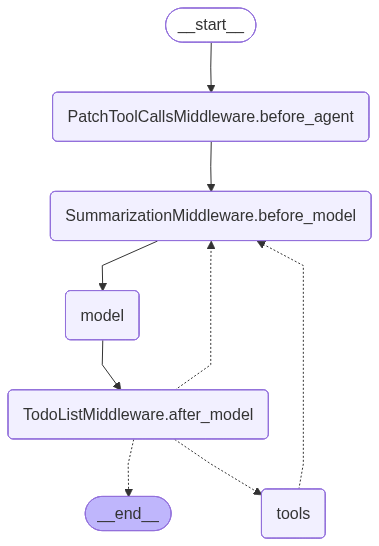

In [25]:
agent

# **Test for the real data : OpenFSMR dataset**

In [26]:
os.environ["LANGSMITH_API_KEY"] =Langsmith_key
os.environ["LANGSMITH_TRACING"] ="true"
os.environ["LANGSMITH_PROJECT"] ="OpenFSMR_1"
os.environ["LANGSMITH_ENDPOINT"]="https://eu.api.smith.langchain.com"

In [27]:
# @title Running on the OpenFSMR dataset


def run_with_timeout(func, timeout, *args, **kwargs):
    """Run a function with a timeout. If it exceeds timeout, return None."""
    with concurrent.futures.ThreadPoolExecutor() as executor:
        future = executor.submit(func, *args, **kwargs)
        try:
            return future.result(timeout=timeout)
        except concurrent.futures.TimeoutError:
            return None


def batch_run_wikidata_match(input_xlsx: str, output_xlsx: str):

    ##################### updated to process unverified #############################
    # Load both sheets
    mappings_df = pd.read_excel(input_xlsx, sheet_name="Mappings")
    defs_df     = pd.read_excel(input_xlsx, sheet_name="Used definitions")

    # Build a dict: term → definition
    def_map = defs_df.set_index("Term")["Definition"].to_dict()

    # Make sure columns exist
    if "Mapped ID" not in mappings_df.columns:
        mappings_df["Mapped ID"] = pd.NA
    if "SKOS_matching" not in mappings_df.columns:
        mappings_df["SKOS_matching"] = pd.NA
    if "SKOS_matching_logic" not in mappings_df.columns:
        mappings_df["SKOS_explanation"] = pd.NA

    mapped_term_str = mappings_df["Mapped ID"].astype("string")


    to_process = mappings_df.copy()

    # For each term with no mapped term yet or unverified...
    for idx, row in to_process.iterrows():
        term = row["Term"]
        definition = def_map.get(term, "")
        if not isinstance(definition, str):
            definition = str(definition)
        definition = definition.strip()

        if not definition:
            # Skip if no definition available
            continue

        # Clear memory for a fresh agent run (assuming you have a memory object)
        if "memory" in globals():
            memory.clear()

        QUESTION_QUERY = f"""What is the best fitting identifier for the term:' {term}' with the definition: '{definition}' """
        #result = agent.invoke({"messages": [{"role": "user", "content": QUESTION_QUERY}]})
        result = run_with_timeout(
            agent.invoke,
            180,  # timeout in seconds
            {"messages": [{"role": "user", "content": QUESTION_QUERY}]},
        )
        if result is None:
    # timed out → treat as "No wiki match"
          print(f"Timeout for term '{term}'. Assigning 'Timeout'.")
          result_text = "Timeout"
        else:
          result_text = result["messages"][-1].content

        # ----- parsing logic (unchanged in spirit) -----
        if isinstance(result_text, str):
            result_text_stripped = result_text.strip()
            try:
                parsed = json.loads(result_text_stripped)
                qid         = parsed.get("ID") or parsed.get("qid")
                skos_match  = parsed.get("SKOS", "")
                explanation = parsed.get("SKOS_explanation", "")
            except json.JSONDecodeError:
                # Treat the plain string as the identifier (or "No wiki match")
                qid         = result_text_stripped
                skos_match  = ""
                explanation = ""
        else:
            qid         = None
            skos_match  = ""
            explanation = ""

        # ----- write results into DataFrame -----

        mappings_df.at[idx, "Mapped ID"]         = qid
        mappings_df.at[idx, "SKOS_matching"]     = skos_match
        mappings_df.at[idx, "SKOS_explanation"]  = explanation

        # ----- save to Excel after each processed row -----
        with pd.ExcelWriter(output_xlsx, engine="openpyxl") as writer:
            mappings_df.to_excel(writer, sheet_name="Mappings", index=False)
            defs_df.to_excel(writer, sheet_name="Used definitions", index=False)

        print(f"Updated row {idx} (term: {term})")

    print(f"Finished batch run; results saved to {output_xlsx}")


In [28]:
# @title Run the system
batch_run_wikidata_match(
    input_xlsx="/content/Model-IndependentVariables_openFSMR_ESWC_21012026_corrected.xlsx",
    output_xlsx="/content/Model-IndependentVariables_openFSMR_ESWC_21012026_corrected_filled.xlsx")

/tmp/ipython-input-974198429.py:87: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Q791576' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  mappings_df.at[idx, "Mapped ID"]         = qid
/tmp/ipython-input-974198429.py:88: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'exact' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  mappings_df.at[idx, "SKOS_matching"]     = skos_match


Updated row 0 (term: Aw)
Updated row 1 (term: CO2)
Updated row 2 (term: CO2_dissolved)
Updated row 3 (term: DiacetateNa)
Updated row 4 (term: Fat)
Updated row 5 (term: Init_level)
Updated row 6 (term: KCl)
Updated row 7 (term: LactateK)
Updated row 8 (term: NO)
Updated row 9 (term: NaCL)
Updated row 10 (term: sodium_nitrite)
Updated row 11 (term: NaNO2)
Updated row 12 (term: Nitrite)
Updated row 13 (term: O2)
Updated row 14 (term: Organic_acid)
Updated row 15 (term: Temp)
Updated row 16 (term: acetic_acid)
Updated row 17 (term: aerobic)
Updated row 18 (term: alpha)
Updated row 19 (term: antimicrobial_dipping_time)
Updated row 20 (term: ascorbic_acid)
Updated row 21 (term: attachment_time)
Updated row 22 (term: bean_oil)
Updated row 23 (term: benzoic_acid)
Updated row 24 (term: citric_acid)
Updated row 25 (term: desired_reduction)
Updated row 26 (term: diacetic_acid)
Updated row 27 (term: disaccharide)
Updated row 28 (term: dry_matter_to_the_mince)
Updated row 29 (term: ethanol)
Updated

# **Second Round - broad**

In [29]:
os.environ["LANGSMITH_API_KEY"] =Langsmith_key
os.environ["LANGSMITH_TRACING"] ="true"
os.environ["LANGSMITH_PROJECT"] ="OpenFSMR_2"
os.environ["LANGSMITH_ENDPOINT"]="https://eu.api.smith.langchain.com"

In [30]:
# Second round to fill missing Bioportal entries and Wikidata with more broad concepts
research_instructions_main_2 = f"""You task is to match the term with valid identifiers from either Bioportal or wikidata.

Start with Bioportal and if no identifiers are found proceed with the wikidata.

When passing the task to Wikidata agent focus more on related matches, meaning that the label may only be associated with the term and knowledge domain.

If an identifier was found, make a SKOS matching between the identifier and the original term using classify_skos_match tool
At the final step send your output to agentmapping_format tool for the final formatting and provide the output of this tool as the final answer.

If an identifier was not found call agentmapping_format tool with empty input for the final formatting and provide the output of this tool as the final answer.

Do not modify the output of agentmapping_format tool

Keep track on what identifiers you tried to avoid repetitive tries
"""

In [31]:
bioportal_subagent = {
    "name": "bioportal-agent",
    "description": "Used to search through bioportal",
    "system_prompt": research_instructions_onto,
    "tools": [find_best_definition, find_term_in_ontology],
    #"model": "openai:gpt-4o",  # Optional override, defaults to main agent model
}

wikidata_subagent = {
    "name": "wikidata-agent",
    "description": "Used to search through wikidata",
    "system_prompt": research_instructions_wiki,
    "tools": [WikidataEntitySearch, WikidataEntityDetails],
    #"model": "openai:gpt-4o",  # Optional override, defaults to main agent model
}

subagents=[bioportal_subagent, wikidata_subagent]
agent = create_deep_agent(model=model,subagents=subagents,system_prompt=research_instructions_main_2, tools=[classify_skos_match,agentmapping_format])

In [36]:
def run_with_timeout(func, timeout, *args, **kwargs):
    """Run a function with a timeout. If it exceeds timeout, return None."""
    with concurrent.futures.ThreadPoolExecutor() as executor:
        future = executor.submit(func, *args, **kwargs)
        try:
            return future.result(timeout=timeout)
        except concurrent.futures.TimeoutError:
            return None


def batch_run_wikidata_match(input_xlsx: str, output_xlsx: str):

    ##################### updated to process unverified #############################
    # Load both sheets
    mappings_df = pd.read_excel(input_xlsx, sheet_name="Mappings",keep_default_na=False)
    defs_df     = pd.read_excel(input_xlsx, sheet_name="Used definitions",keep_default_na=False)

    # Build a dict: term → definition
    def_map = defs_df.set_index("Term")["Definition"].to_dict()

    # Make sure columns exist
    if "Mapped ID" not in mappings_df.columns:
        mappings_df["Mapped ID"] = pd.NA
    if "SKOS_matching" not in mappings_df.columns:
        mappings_df["SKOS_matching"] = pd.NA
    if "SKOS_matching_logic" not in mappings_df.columns:
        mappings_df["SKOS_explanation"] = pd.NA

    mapped_term_str = mappings_df["Mapped ID"].astype("string")

    #mask_no_match = mapped_term_str.str.contains("None", case=False, na=False)
    #mask_empty    = mapped_term_str.isna() | (mapped_term_str.str.strip() == "")
    #mask_to_process = mask_no_match | mask_empty

    mask_no_match = (mapped_term_str.eq("None"))                             # exact match
    to_process = mappings_df[mask_no_match].copy()

    # For each term with no mapped term yet or unverified...
    for idx, row in to_process.iterrows():
        term = row["Term"]
        definition = def_map.get(term, "")
        if not isinstance(definition, str):
            definition = str(definition)
        definition = definition.strip()

        if not definition:
            # Skip if no definition available
            continue

        # Clear memory for a fresh agent run (assuming you have a memory object)
        if "memory" in globals():
            memory.clear()

        QUESTION_QUERY = f"""What is the best fitting identifier for the term:' {term}' with the definition: '{definition}' """
        #result = agent.invoke({"messages": [{"role": "user", "content": QUESTION_QUERY}]})
        result = run_with_timeout(
            agent.invoke,
            180,  # timeout in seconds
            {"messages": [{"role": "user", "content": QUESTION_QUERY}]},
        )
        if result is None:
    # timed out → treat as "No wiki match"
          print(f"Timeout for term '{term}'. Assigning 'Timeout'.")
          result_text = "Timeout"
        else:
          result_text = result["messages"][-1].content

        # ----- parsing logic (unchanged in spirit) -----
        if isinstance(result_text, str):
            result_text_stripped = result_text.strip()
            try:
                parsed = json.loads(result_text_stripped)
                qid         = parsed.get("ID") or parsed.get("qid")
                skos_match  = parsed.get("SKOS", "")
                explanation = parsed.get("SKOS_explanation", "")
            except json.JSONDecodeError:
                # Treat the plain string as the identifier (or "No wiki match")
                qid         = result_text_stripped
                skos_match  = ""
                explanation = ""
        else:
            qid         = None
            skos_match  = ""
            explanation = ""

        # ----- write results into DataFrame -----

        mappings_df.at[idx, "Mapped ID"]         = qid
        mappings_df.at[idx, "SKOS_matching"]     = skos_match
        mappings_df.at[idx, "SKOS_explanation"]  = explanation

        # ----- save to Excel after each processed row -----
        with pd.ExcelWriter(output_xlsx, engine="openpyxl") as writer:
            mappings_df.to_excel(writer, sheet_name="Mappings", index=False)
            defs_df.to_excel(writer, sheet_name="Used definitions", index=False)

        print(f"Updated row {idx} (term: {term})")

    print(f"Finished batch run; results saved to {output_xlsx}")

In [37]:
batch_run_wikidata_match(
    input_xlsx="/content/Model-IndependentVariables_openFSMR_ESWC_21012026_corrected_filled.xlsx",
    output_xlsx="/content/Model-IndependentVariables_openFSMR_ESWC_21012026_corrected_filled_broad.xlsx")

Updated row 2 (term: CO2_dissolved)
Updated row 3 (term: DiacetateNa)
Updated row 5 (term: Init_level)
Updated row 7 (term: LactateK)
Updated row 8 (term: NO)
Updated row 19 (term: antimicrobial_dipping_time)
Updated row 21 (term: attachment_time)
Updated row 25 (term: desired_reduction)
Updated row 28 (term: dry_matter_to_the_mince)
Updated row 33 (term: gel_microstructure)
Updated row 35 (term: inhibiting_Effekt_LAB-Lm)
Timeout for term 'init_aqueous_salt'. Assigning 'Timeout'.
Updated row 36 (term: init_aqueous_salt)
Updated row 37 (term: init_level)
Updated row 38 (term: init_level_LAB)
Updated row 39 (term: init_level_Mm)
Updated row 40 (term: init_level_histamine)
Updated row 41 (term: init_level_histidine)
Updated row 43 (term: kmax)
Updated row 46 (term: logDvalue0)
Updated row 47 (term: meat_content)
Updated row 59 (term: relative_humidity)
Updated row 60 (term: salt-sugar)
Updated row 61 (term: sh)
Updated row 62 (term: shelf-life_ReferenceTemp)
Updated row 63 (term: slices_n

# Combining results together and Resolving IRIS

In [2]:
# @title Results combining
import re
import openpyxl

FILE_1 = "/content/Model-IndependentVariables_openFSMR_ESWC_21012026_corrected_filled.xlsx"
FILE_2 = "/content/Model-IndependentVariables_openFSMR_ESWC_21012026_corrected_filled_broad.xlsx"
OUT_FILE = "/content/Model-IndependentVariables_openFSMR_ESWC_21012026_corrected_filled_combined.xlsx"
SHEET = "Mappings"
TERM_COL_NAME = "Term"

def norm(s):
    return re.sub(r"\s+", " ", str(s or "")).strip().lower()

def is_none_like(v):
    if v is None:
        return True
    s = str(v).strip()
    return s == "" or s.lower() == "none"

def header_map(ws, header_row=1):
    """Return {normalized_header: col_index} for a fixed-structure sheet."""
    m = {}
    for c in range(1, ws.max_column + 1):
        h = ws.cell(header_row, c).value
        if h is not None and str(h).strip() != "":
            m[norm(h)] = c
    return m

def build_term_row_index(ws, term_col, header_row=1):
    idx = {}
    for r in range(header_row + 1, ws.max_row + 1):
        term = ws.cell(r, term_col).value
        if term is None:
            continue
        key = str(term).strip()
        if key and key not in idx:
            idx[key] = r
    return idx

def main():
    wb1 = openpyxl.load_workbook(FILE_1)
    wb2 = openpyxl.load_workbook(FILE_2)

    ws1 = wb1[SHEET]
    ws2 = wb2[SHEET]

    # Assuming fixed structure: headers on row 1
    h1 = header_map(ws1, header_row=1)
    h2 = header_map(ws2, header_row=1)

    term_col1 = h1.get(norm(TERM_COL_NAME))
    term_col2 = h2.get(norm(TERM_COL_NAME))
    if not term_col1 or not term_col2:
        raise ValueError(f"Couldn't find '{TERM_COL_NAME}' column in one of the files.")

    # Only copy columns that exist in BOTH files (by header name)
    common_headers = set(h1.keys()) & set(h2.keys())
    common_headers.discard(norm(TERM_COL_NAME))  # don't overwrite Term

    term_to_row2 = build_term_row_index(ws2, term_col2, header_row=1)

    replaced_cells = 0
    matched_rows = 0
    missing_terms = 0

    for r1 in range(2, ws1.max_row + 1):
        term = ws1.cell(r1, term_col1).value
        if term is None:
            continue
        term_key = str(term).strip()
        if not term_key:
            continue

        r2 = term_to_row2.get(term_key)
        if r2 is None:
            missing_terms += 1
            continue

        matched_rows += 1

        for hdr in common_headers:
            c1 = h1[hdr]
            c2 = h2[hdr]

            v1 = ws1.cell(r1, c1).value
            if is_none_like(v1):
                v2 = ws2.cell(r2, c2).value
                # Only replace if file_2 actually has something non-empty
                if not is_none_like(v2):
                    ws1.cell(r1, c1).value = v2
                    replaced_cells += 1

    wb1.save(OUT_FILE)
    print(f"Matched rows: {matched_rows}")
    print(f"Missing Terms in file_2: {missing_terms}")
    print(f"Replaced cells: {replaced_cells}")
    print(f"Saved: {OUT_FILE}")

if __name__ == "__main__":
    main()



Matched rows: 84
Missing Terms in file_2: 0
Replaced cells: 31
Saved: /content/Model-IndependentVariables_openFSMR_ESWC_21012026_corrected_filled_combined.xlsx


In [5]:
# @title Make URLS from Indentifiers
import re
import openpyxl

INPUT_FILE = "/content/Model-IndependentVariables_openFSMR_ESWC_21012026_corrected_filled_combined_IS.xlsx"
OUTPUT_FILE = "/content/Model-IndependentVariables_openFSMR_ESWC_21012026_corrected_filled_combined_IS_iri_1.xlsx"

SHEET_NAME = "Mappings"
HEADER_ROW = 1
MAPPED_ID_COL_NAME = "Mapped ID"

# Regex patterns
# separator can be :, _, -, or space (one or more)
WIKIDATA_RE = re.compile(r"^(Q\d+)$")
CHEBI_RE    = re.compile(r"^CHEBI[:_\-\s]+(\S+)$")
SNOMED_RE   = re.compile(r"^SNOMEDCT[:_\-\s]+(\S+)$")
NCIT_RE     = re.compile(r"^NCIT[:_\-\s]+(\S+)$")

def transform_mapped_id(value):
    if value is None:
        return None

    s = str(value).strip()

    m = WIKIDATA_RE.match(s)
    if m:
        return f"https://www.wikidata.org/wiki/{m.group(1)}"

    m = CHEBI_RE.match(s)
    if m:
        return f"http://purl.obolibrary.org/obo/CHEBI_{m.group(1)}"

    m = SNOMED_RE.match(s)
    if m:
        return f"http://purl.bioontology.org/ontology/SNOMEDCT/{m.group(1)}"

    m = NCIT_RE.match(s)
    if m:
        return f"http://purl.obolibrary.org/obo/NCIT_{m.group(1)}"

    return value  # unchanged

def main():
    wb = openpyxl.load_workbook(INPUT_FILE)
    ws = wb[SHEET_NAME]

    # Find "Mapped ID" column (exact match, no normalization)
    mapped_col = None
    for c in range(1, ws.max_column + 1):
        if ws.cell(HEADER_ROW, c).value == MAPPED_ID_COL_NAME:
            mapped_col = c
            break

    if mapped_col is None:
        raise ValueError(f"Column '{MAPPED_ID_COL_NAME}' not found.")

    updated = 0
    for r in range(HEADER_ROW + 1, ws.max_row + 1):
        cell = ws.cell(r, mapped_col)
        new_val = transform_mapped_id(cell.value)
        if new_val != cell.value:
            cell.value = new_val
            updated += 1

    wb.save(OUTPUT_FILE)
    print(f"Updated cells: {updated}")
    print(f"Saved: {OUTPUT_FILE}")

if __name__ == "__main__":
    main()

Updated cells: 33
Saved: /content/Model-IndependentVariables_openFSMR_ESWC_21012026_corrected_filled_combined_IS_iri_1.xlsx


In [8]:
# @title Resolving IRIs

"""
Cascading ontology lookup (Colab/Jupyter compatible):
1. OLS
2. BioPortal
3. Ontobee
Falls through until one service confirms the IRI.
"""

from __future__ import annotations
import yaml, urllib.parse, re, os
import pandas as pd
from tqdm.asyncio import tqdm
from typing import Dict, Callable, Optional, Any
import aiohttp
import asyncio

# -------------------------------------------------------------------------- #
# YAML loader                                                                 #
# -------------------------------------------------------------------------- #
def load_api_specs(path: str) -> Dict[str, Any]:
    with open(path, "r", encoding="utf-8") as fh:
        return yaml.safe_load(fh)

# -------------------------------------------------------------------------- #
# Utility: build a human-readable link                                        #
# -------------------------------------------------------------------------- #
def make_ui_link(template: str, acronym: str, iri: str) -> str:
    return template.format(
        acronym     = acronym,
        encoded_iri = urllib.parse.quote_plus(iri),
        iri         = iri,
    )

# -------------------------------------------------------------------------- #
# Parsers                                                                     #
# -------------------------------------------------------------------------- #
def parse_bioportal(payload: dict, iri: str, spec: dict) -> Optional[dict]:
    for hit in payload.get("collection", []):
        if hit.get("@id") == iri:
            acr_url = hit.get("links", {}).get("ontology", "")
            acr = acr_url.rstrip("/").split("/")[-1].upper()
            return {
                "label":   hit.get("prefLabel"),
                "acronym": acr,
                "ui_link": make_ui_link(spec["ui_template"], acr, iri),
            }

def parse_ols(payload: dict, iri: str, spec: dict) -> Optional[dict]:
    for doc in payload.get("response", {}).get("docs", []):
        if doc.get("iri") == iri:
            acr = (doc.get("ontology_name") or "").upper()
            return {
                "label":   doc.get("label"),
                "acronym": acr,
                "ui_link": make_ui_link(spec["ui_template"], acr, iri),
            }

_ONT_ABBR_RX = re.compile(r"/obo/([A-Za-z0-9]+)[_#/]")

def parse_ontobee(payload: dict, iri: str, spec: dict) -> Optional[dict]:
    if payload.get("boolean"):
        m   = _ONT_ABBR_RX.search(iri)
        acr = m.group(1).upper() if m else "UNKNOWN"
        return {
            "acronym": acr,
            "ui_link": make_ui_link(spec["ui_template"], acr, iri),
        }

PARSER_MAP: Dict[str, Callable[[Any, str, dict], Optional[dict]]] = {
    "bioportal": parse_bioportal,
    "ols":       parse_ols,
    "ontobee":   parse_ontobee,
}

# -------------------------------------------------------------------------- #
# Network call                                                                #
# -------------------------------------------------------------------------- #
async def call_api(session: aiohttp.ClientSession, spec: dict, iri: str) -> Optional[dict]:
    base   = spec["base_url"].rstrip("/")
    url    = f"{base}{spec['lookup_endpoint']}"
    params = spec.get("params", {}).copy()
    headers: dict[str, str] = {}

    # BioPortal auth if configured
    api_key = spec.get("api_key") or os.getenv("BIOPORTAL_KEY")
    if api_key:
        headers["Authorization"] = f"apikey token={api_key}"

    # Each service expects its own query field(s)
    if spec["parser"] == "ontobee":
        params["query"]  = f"ASK WHERE {{ <{iri}> ?p ?o }}"
        params["format"] = "json"
    else:
        params.setdefault("q", iri)

    try:
        async with session.get(url, params=params, headers=headers, timeout=aiohttp.ClientTimeout(total=10)) as resp:
            resp.raise_for_status()
            return await resp.json()
    except (aiohttp.ClientError, asyncio.TimeoutError) as exc:
        print(f"[WARN] {spec['parser']} call failed for {iri}: {exc}")
        return None

# -------------------------------------------------------------------------- #
# One service lookup                                                          #
# -------------------------------------------------------------------------- #
async def lookup_iri_in_source(session: aiohttp.ClientSession, spec: dict, iri: str) -> Optional[dict]:
    raw = await call_api(session, spec, iri)
    if raw is None:
        return None
    hit = PARSER_MAP[spec["parser"]](raw, iri, spec)
    if hit:
        hit["source"] = spec["parser"].upper()
        hit["iri"]    = iri
    return hit

# -------------------------------------------------------------------------- #
# Cascade over all configured services                                         #
# -------------------------------------------------------------------------- #
async def lookup_iri_cascade(session: aiohttp.ClientSession, iri: str, specs: Dict[str, dict]) -> dict:
    if not isinstance(iri, str):
        return {"source": "None", "iri": iri, "message": "Invalid IRI provided."}

    if iri.startswith("https://www.wikidata.org/wiki/"):
        return {
            "source":  "WIKIDATA",
            "iri":     iri,
            "ui_link": iri,
            "label":   "Wikidata Entity",
            "acronym": "WIKIDATA",
        }

    for name, spec in specs.items():
        result = await lookup_iri_in_source(session, spec, iri)
        if result:
            return result

    return {"source": "None", "iri": iri, "message": "IRI not found in any source."}

# -------------------------------------------------------------------------- #
# Data-frame helper                                                           #
# -------------------------------------------------------------------------- #
async def process_iris_async(df: pd.DataFrame, specs: Dict[str, dict], concurrency_limit: int = 10) -> pd.DataFrame:
    semaphore = asyncio.Semaphore(concurrency_limit)

    async def process_one(session: aiohttp.ClientSession, iri: Any) -> dict:
        async with semaphore:
            return await lookup_iri_cascade(session, iri, specs)

    async with aiohttp.ClientSession() as session:
        tasks = [process_one(session, row["Mapped ID"]) for _, row in df.iterrows()]
        results = await tqdm.gather(*tasks, desc="Processing IRIs")

    return pd.DataFrame(results)

# -------------------------------------------------------------------------- #
# Notebook/Colab entrypoint                                                   #
# -------------------------------------------------------------------------- #
# async def main_async(
#     num_to_process: int | None = None,
#     specs_path: str = "/content/api_specs.yaml",
#     input_file: str = "/content/Model-IndependentVariables_openFSMR_ESWC_21012026_corrected_filled_broad.xlsx",
#     output_file: str = "/content/Model-IndependentVariables_openFSMR_ESWC_21012026_corrected_filled_broad_iri.xlsx",
#     concurrency: int = 5,
# ) -> None:
#     specs = load_api_specs(specs_path)

#     df = pd.read_excel(input_file)
#     if num_to_process is not None:
#         df = df.head(num_to_process)

#     results_df = await process_iris_async(df, specs, concurrency_limit=concurrency)
#     combined   = pd.concat([df, results_df], axis=1)

#     # Write results (new file is simplest/cleanest in Colab)
#     with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
#         combined.to_excel(writer, sheet_name="resolved_iris", index=False)

#     print(f"Processing complete. Results saved to sheet 'resolved_iris' in {output_file}")



# -------------------------------------------------------------------------- #
# Notebook/Colab entrypoint                                                   #
# -------------------------------------------------------------------------- #
async def main_async(
    num_to_process: int | None = None,
    specs_path: str = "/content/api_specs.yaml",
    input_file: str = "/content/Model-IndependentVariables_openFSMR_ESWC_21012026_corrected_filled_combined_IS_iri_1.xlsx",
    output_file: str = "/content/Model-IndependentVariables_openFSMR_ESWC_21012026_corrected_filled_combined_IS_iri_1.xlsx",
    concurrency: int = 5,
) -> None:
    specs = load_api_specs(specs_path)

    # Read ONLY the Mappings sheet
    df = pd.read_excel(input_file, sheet_name="Mappings")

    if num_to_process is not None:
        df = df.head(num_to_process)

    # Resolve IRIs
    results_df = await process_iris_async(df, specs, concurrency_limit=concurrency)

    # Write ONLY to a separate sheet named "resolved_iris"
    with pd.ExcelWriter(
        output_file,
        engine="openpyxl",
        mode="a",
        if_sheet_exists="replace"
    ) as writer:
        results_df.to_excel(writer, sheet_name="resolved_iris", index=False)

    print(
        "Processing complete. "
        "Results saved to sheet 'resolved_iris' "
        f"in {output_file}"
    )


In [9]:
await main_async(num_to_process=None, concurrency=5)

Processing IRIs: 100%|██████████| 84/84 [00:15<00:00,  5.44it/s]

Processing complete. Results saved to sheet 'resolved_iris' in /content/Model-IndependentVariables_openFSMR_ESWC_21012026_corrected_filled_combined_IS_iri_1.xlsx


In [ ]:
# @title Inspect the results. All trials combined, terms with no definitions (not used in mapping) are removed
xlsx_path= '/content/Model-IndependentVariables_openFSMR_ESWC_combined_formatted.xlsx'
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# --- Load Excel ---
df = pd.read_excel(xlsx_path)

# --- Create scrollable HTML table ---
scrollable_html = (
    "<div style='max-height:600px; overflow:auto; border:1px solid lightgray;'>"
    + df.to_html(index=True, justify='left')
    + "</div>"
)

# --- Display ---
display(HTML(scrollable_html))



,Term,Mapped ID,SKOS_matching,SKOS_explanation
0,Aw,Q791576,exact,"Both concepts describe the same physical property, water activity (Aw), as it relates to food and microbial growth. Concept A gives the precise thermodynamic definition and scale (0–1), while Concept B highlights its role in limiting microbial activity. They refer to the same underlying concept and can be used interchangeably."
1,CO2,http://purl.obolibrary.org/obo/CHEBI_16526,exact,"Both concepts denote the same chemical substance, carbon dioxide (CO₂). Concept A emphasizes its role as an environmental parameter in food-safety modeling, while Concept B provides the general chemical and toxicological definition of CO₂. Despite the differing contextual focus, they refer to the identical real-world compound, so they are exact matches across schemes."
2,CO2_dissolved,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C65288,close,"Both concepts refer to the same chemical substance, carbon dioxide, but in different contexts: Concept B is the general notion of CO₂ as a gas, while Concept A is specifically its concentration when dissolved in an aqueous food matrix, used as a variable in food-safety models. Thus they are closely related (same substance) but not strictly interchangeable, since A is a quantitative state/property of B in a specific medium and application."
3,DiacetateNa,http://purl.bioontology.org/ontology/MESH/C548838,exact,"Both concepts denote the same chemical food additive, sodium diacetate, described as a food‑grade sodium salt of acetic acid used as an acidulant and antimicrobial preservative. Concept A’s mention of its role as an independent variable in predictive FSM is a specific usage context, not a different concept, so they are semantically equivalent."
4,Fat,NaN,NaN,"No suitable BioPortal or Wikidata identifier was found that accurately represents the concept, therefore no SKOS mapping (ID, SKOS, or explanation) can be provided."
5,Init_level,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C85644,closeMatch,"The NCIT concept C85644 “Initial Concentration” represents a starting measured concentration and aligns with the notion of an initial quantitative level used as a baseline in modeling, which is conceptually close to “Init_level” as the initial microbial concentration in a food matrix. However, it is defined in the context of compounds (often drugs) in pharmacology rather than microorganisms in food, so it is not fully equivalent but is the closest available ontology term, warranting a closeMatch rather than an exactMatch."
6,KCl,http://purl.obolibrary.org/obo/CHEBI_32588,exact,"Both concepts denote potassium chloride (KCl). Concept A gives a food‐science–oriented usage and role (sodium replacer, preservative, modeling variable), while Concept B gives a role‑neutral chemical classification (a metal chloride salt with K⁺). They refer to the same chemical substance, so they are exact matches semantically."
7,LactateK,Q325519,close,"Both concepts refer to an acid dissociation constant (Ka): Concept B is the general notion of the acid dissociation constant, while LactateK in Concept A is the specific Ka value for lactic acid used in food-safety modeling. Thus, LactateK is a specific instance/application of the general acid dissociation constant concept, making them closely related but not fully interchangeable."
8,NO,NO,related,"The tool explicitly reports 'NO ontology match was found in BioPortal or Wikidata', so there is no valid external concept identifier. The string 'NO' is therefore treated as a placeholder indicating absence of mapping rather than a true ontology concept; the SKOS relation is set to 'related' only to encode that this is not a semantic match but a negative mapping result."
9,NaCL,http://ncicb.nci.nih.gov/xml/owl/EVS/Thesaurus.owl#C29974,exact,"Both concepts denote the same chemical substance, sodium chloride (table salt). Concept A focuses on its quantitative concentration as a variable in food‐safety modeling, while